# Hafta 11: Gen İfadesi Verisi: Normalizasyon, Keşifsel Analiz ve Diferansiyel İfade

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. RNA-seq iş akışını ve sayım (count) matrisinin yapısını anlamak.
2. CPM, TPM ve medyan-oranlar (DESeq2 tarzı) normalizasyonlarını elle ve kodla hesaplamak.
3. Örnek korelasyonu, dağılım grafikleri ve PCA ile veriyi keşfetmek.
4. Katlanma değişimi (log2FC), t-testi ve çoklu test düzeltmesi (Bonferroni, Benjamini–Hochberg) ile diferansiyel ifade analizi yapmak.
5. Sonuçları gerçek cevapla karşılaştırıp **kesinlik/duyarlılık** kavramlarına (makine öğrenmesine köprü) giriş yapmak.

**Veri:** `ifade_sayimlar.csv` (2000 gen × 12 örnek, sentetik RNA-seq sayımları), `ornek_bilgisi.csv`, `gercek_de_genler.csv` (150 gerçek DE gen)

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_ifade(klasor="veri"):
    """ifade_sayimlar.csv (RNA-seq benzeri ham sayımlar), ornek_bilgisi.csv, gercek_de_genler.csv"""
    import os
    import numpy as np
    import pandas as pd
    os.makedirs(klasor, exist_ok=True)
    rng = np.random.default_rng(3)
    G, n = 2000, 12
    genler = [f"GEN{i:04d}" for i in range(1, G + 1)]
    ornekler = [f"K{i}" for i in range(1, 7)] + [f"T{i}" for i in range(1, 7)]
    grup = ["kontrol"] * 6 + ["tedavi"] * 6
    temel = np.exp(rng.normal(4.5, 1.6, G))              # gen başına ortalama ifade
    fc = np.ones(G)
    de = rng.choice(G, 150, replace=False)
    yukari, asagi = de[:75], de[75:]
    fc[yukari] = 2 ** rng.uniform(1, 3, 75)
    fc[asagi] = 2 ** -rng.uniform(1, 3, 75)
    kutuphane = rng.uniform(0.6, 1.5, n)
    disp = 0.08
    sayim = np.zeros((G, n), dtype=int)
    for j in range(n):
        mu = temel * kutuphane[j] * (fc if grup[j] == "tedavi" else 1)
        lam = rng.gamma(1 / disp, mu * disp)
        sayim[:, j] = rng.poisson(lam)
    pd.DataFrame(sayim, index=pd.Index(genler, name="gen"), columns=ornekler).to_csv(
        os.path.join(klasor, "ifade_sayimlar.csv"))
    pd.DataFrame({"ornek": ornekler, "grup": grup,
                  "kutuphane_carpani": np.round(kutuphane, 3)}).to_csv(
        os.path.join(klasor, "ornek_bilgisi.csv"), index=False)
    pd.DataFrame({"gen": [genler[i] for i in de],
                  "yon": ["yukari"] * 75 + ["asagi"] * 75,
                  "gercek_log2FC": np.round(np.log2(fc[de]), 3)}).to_csv(
        os.path.join(klasor, "gercek_de_genler.csv"), index=False)


if not os.path.exists('veri/ifade_sayimlar.csv'):
    veri_uret_ifade()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'gercek_de_genler.csv', 'ifade_sayimlar.csv', 'ornek_bilgisi.csv']


## 1. RNA-seq iş akışı
```
Doku / hücre  →  RNA izolasyonu  →  cDNA kütüphanesi  →  Dizileme (FASTQ)
      →  Kalite kontrol (4. hafta)  →  Referansa hizalama / pseudo-hizalama  →  Gen başına okuma sayımı
      →  SAYIM MATRİSİ (gen × örnek)  →  Normalizasyon  →  Keşifsel analiz  →  Diferansiyel ifade  →  Biyolojik yorum
```
Bu hafta **sayım matrisinden** sonrasını ele alıyoruz. Sayımlar negatif olmayan tamsayılardır ve varyansları ortalamayla birlikte artar
(Poisson'dan daha fazla: **negatif binom** dağılımı).

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

sayim = pd.read_csv("veri/ifade_sayimlar.csv", index_col=0)
bilgi = pd.read_csv("veri/ornek_bilgisi.csv")
gercek = pd.read_csv("veri/gercek_de_genler.csv")
print(sayim.shape)
display(sayim.head())
display(bilgi)

(2000, 12)


,K1,K2,K3,K4,K5,K6,T1,T2,T3,T4,T5,T6
gen,,,,,,,,,,,,
GEN0001,1534,1206,2545,2168,2182,3341,1861,2269,2058,2311,3040,1938
GEN0002,1,1,1,1,0,4,1,2,1,3,2,1
GEN0003,50,81,81,68,277,272,260,102,137,261,233,143
GEN0004,19,17,45,27,33,67,50,35,38,67,55,35
GEN0005,49,24,55,34,53,41,29,21,37,45,64,34


,ornek,grup,kutuphane_carpani
0,K1,kontrol,0.663
1,K2,kontrol,0.672
2,K3,kontrol,0.657
3,K4,kontrol,0.757
4,K5,kontrol,0.735
5,K6,kontrol,1.383
6,T1,tedavi,1.084
7,T2,tedavi,0.643
8,T3,tedavi,0.759
9,T4,tedavi,1.334


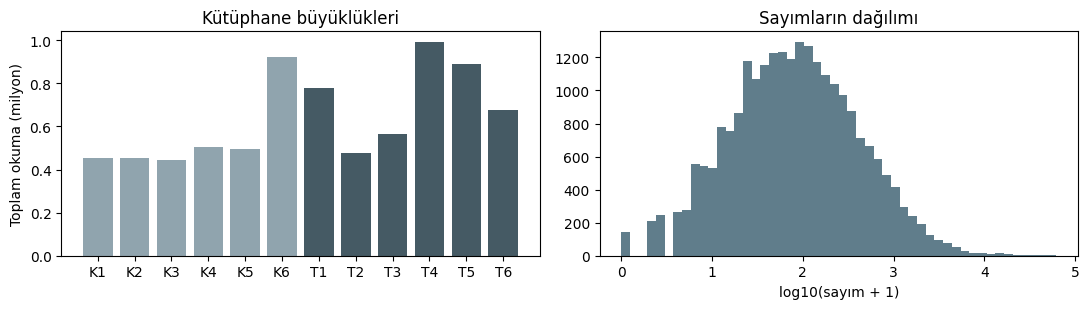

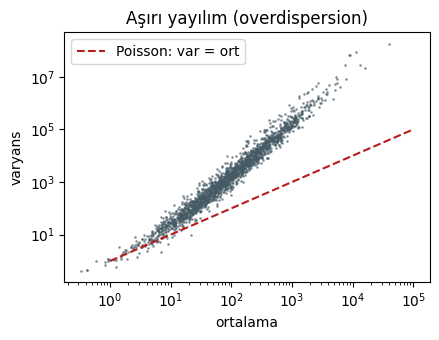

In [4]:
kutuphane = sayim.sum(axis=0)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(kutuphane.index, kutuphane / 1e6, color=["#90a4ae"] * 6 + ["#455a64"] * 6)
ax[0].set_ylabel("Toplam okuma (milyon)"); ax[0].set_title("Kütüphane büyüklükleri")
ax[1].hist(np.log10(sayim.values.flatten() + 1), bins=50, color="#607d8b")
ax[1].set_xlabel("log10(sayım + 1)"); ax[1].set_title("Sayımların dağılımı")
plt.tight_layout(); plt.show()
ort, var = sayim.mean(axis=1), sayim.var(axis=1)
plt.figure(figsize=(4.5, 3.5)); plt.loglog(ort, var, ".", ms=2, color="#455a64", alpha=0.5)
plt.loglog([1, 1e5], [1, 1e5], "--", color="#b71c1c", label="Poisson: var = ort")
plt.xlabel("ortalama"); plt.ylabel("varyans"); plt.legend(); plt.title("Aşırı yayılım (overdispersion)"); plt.tight_layout(); plt.show()

## 2. Normalizasyon
Örnekler farklı derinlikte dizilendiği için ham sayımlar doğrudan karşılaştırılamaz.

| Yöntem | Formül | Düzelttiği |
|---|---|---|
| CPM | $\dfrac{c_{gi}}{\sum_g c_{gi}}\times10^6$ | Dizileme derinliği |
| TPM | $RPK_{gi}=\dfrac{c_{gi}}{L_g/1000}$, $TPM=\dfrac{RPK_{gi}}{\sum_g RPK_{gi}}\times10^6$ | Derinlik + gen uzunluğu |
| Medyan-oranlar (DESeq2) | $s_i = \text{medyan}_g \dfrac{c_{gi}}{(\prod_j c_{gj})^{1/n}}$ | Derinlik + kompozisyon |

### Sayısal örnek — CPM ve TPM
Tek bir örnekte üç gen: A (2 kb, 200 okuma), B (3 kb, 300 okuma), C (1 kb, 500 okuma). Toplam 1000 okuma.

| Gen | Okuma | Uzunluk | CPM | RPK | TPM |
|---|---|---|---|---|---|
| A | 200 | 2 kb | 200 000 | 100 | 142 857 |
| B | 300 | 3 kb | 300 000 | 100 | 142 857 |
| C | 500 | 1 kb | 500 000 | 500 | 714 286 |

CPM'e göre B, A'dan fazla ifade ediliyor gibi görünür; uzunluk düzeltmesi (TPM) sonrası ikisinin eşit olduğu anlaşılır.
**Aynı gen farklı örneklerde** karşılaştırılırken uzunluk sabittir; bu yüzden diferansiyel ifadede CPM/medyan-oranlar yeterlidir.

In [5]:
ornek = pd.DataFrame({"okuma": [200, 300, 500], "uzunluk_kb": [2, 3, 1]}, index=list("ABC"))
ornek["CPM"] = ornek.okuma / ornek.okuma.sum() * 1e6
ornek["RPK"] = ornek.okuma / ornek.uzunluk_kb
ornek["TPM"] = ornek.RPK / ornek.RPK.sum() * 1e6
ornek.round(0)

,okuma,uzunluk_kb,CPM,RPK,TPM
A,200,2,200000.0,100.0,142857.0
B,300,3,300000.0,100.0,142857.0
C,500,1,500000.0,500.0,714286.0


In [6]:
cpm = sayim / sayim.sum(axis=0) * 1e6
logcpm = np.log2(cpm + 1)

def medyan_oranlar(c):
    log_c = np.log(c.replace(0, np.nan))
    log_geo = log_c.mean(axis=1)                      # geometrik ortalama (log ölçekte aritmetik)
    gecerli = log_geo.notna() & np.isfinite(log_geo)  # sıfır içeren genler dışarıda
    return np.exp((log_c[gecerli].sub(log_geo[gecerli], axis=0)).median(axis=0))

s = medyan_oranlar(sayim)
karsilastir = pd.DataFrame({"tahmini_boyut_faktoru": s.round(3), "gercek_kutuphane_carpani": bilgi.set_index("ornek").kutuphane_carpani})
karsilastir["oran"] = (karsilastir.iloc[:, 0] / karsilastir.iloc[:, 1]).round(3)
karsilastir

,tahmini_boyut_faktoru,gercek_kutuphane_carpani,oran
K1,0.776,0.663,1.170
K2,0.805,0.672,1.198
K3,0.783,0.657,1.192
K4,0.902,0.757,1.192
K5,0.870,0.735,1.184
K6,1.650,1.383,1.193
T1,1.286,1.084,1.186
T2,0.750,0.643,1.166
T3,0.913,0.759,1.203
T4,1.603,1.334,1.202


> Tahmini boyut faktörleri gerçek kütüphane çarpanlarıyla **sabit bir oran** dışında birebir uyuşuyor (ölçek önemsizdir).
Tedavi örneklerinde oran biraz farklıysa bunun nedeni DE genlerin kompozisyonu etkilemesidir.

## 3. Filtreleme ve keşifsel analiz
Çok düşük ifade edilen genler gürültülüdür ve test sayısını gereksiz yere artırır.

Filtre öncesi 2000 gen, sonrası 1941 gen


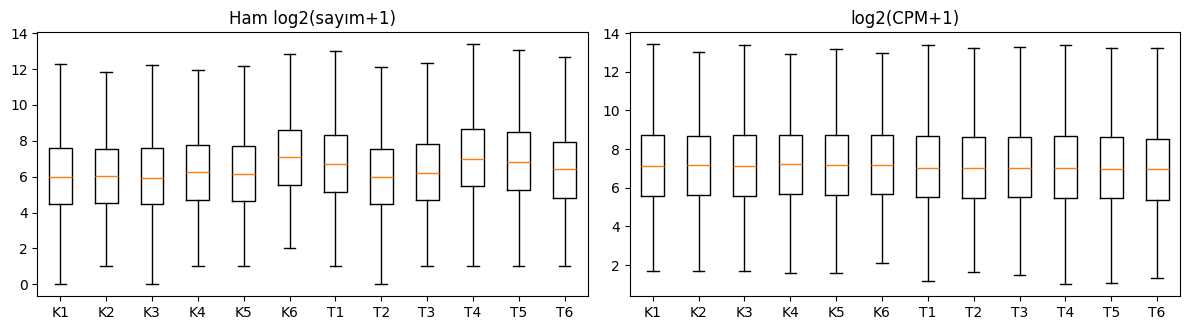

In [7]:
tut = (cpm >= 10).sum(axis=1) >= 3           # en az 3 örnekte CPM >= 10
print(f"Filtre öncesi {len(sayim)} gen, sonrası {tut.sum()} gen")
X = logcpm[tut]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].boxplot(np.log2(sayim[tut] + 1).values, tick_labels=sayim.columns, showfliers=False); ax[0].set_title("Ham log2(sayım+1)")
ax[1].boxplot(X.values, tick_labels=X.columns, showfliers=False); ax[1].set_title("log2(CPM+1)")
plt.tight_layout(); plt.show()

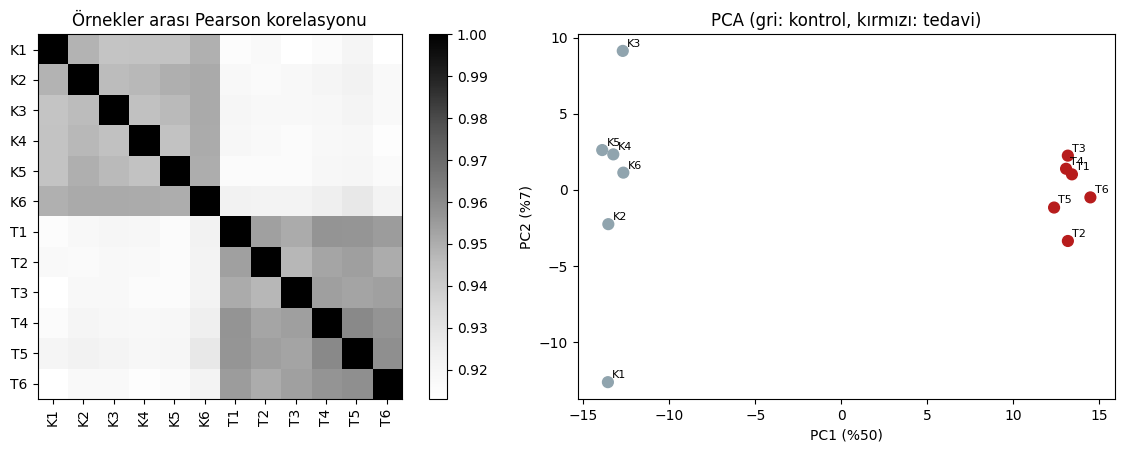

In [8]:
kor = X.corr(method="pearson")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
im = ax[0].imshow(kor, cmap="Greys", vmin=kor.values.min(), vmax=1)
ax[0].set_xticks(range(12)); ax[0].set_xticklabels(kor.columns, rotation=90); ax[0].set_yticks(range(12)); ax[0].set_yticklabels(kor.index)
ax[0].set_title("Örnekler arası Pearson korelasyonu"); plt.colorbar(im, ax=ax[0])

# PCA (12. haftada ayrıntılı): en değişken 500 gen
from sklearn.decomposition import PCA
degisken = X.var(axis=1).sort_values(ascending=False).index[:500]
Z = X.loc[degisken].T
Z = Z - Z.mean()
pca = PCA(n_components=2).fit(Z)
pc = pca.transform(Z)
renk = ["#90a4ae" if g == "kontrol" else "#b71c1c" for g in bilgi.grup]
ax[1].scatter(pc[:, 0], pc[:, 1], c=renk, s=60)
for i, ad in enumerate(X.columns):
    ax[1].annotate(ad, (pc[i, 0], pc[i, 1]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax[1].set_xlabel(f"PC1 (%{100*pca.explained_variance_ratio_[0]:.0f})"); ax[1].set_ylabel(f"PC2 (%{100*pca.explained_variance_ratio_[1]:.0f})")
ax[1].set_title("PCA (gri: kontrol, kırmızı: tedavi)"); plt.tight_layout(); plt.show()

## 4. Diferansiyel ifade (DE)
Her gen için hipotez testi: $H_0$: iki grubun ortalama ifadesi eşittir.

**Katlanma değişimi:** $\log_2 FC = \overline{x}_{tedavi} - \overline{x}_{kontrol}$ (log ölçekte fark). log2FC = 1 → 2 kat artış, −1 → yarıya düşüş.

**Welch t-testi:** $t = \dfrac{\bar{x}_1-\bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}$

### Sayısal örnek
Kontrol: 5, 6, 7; Tedavi: 9, 10, 11 (log2 ifade). $\bar x_K = 6$, $\bar x_T = 10$, $s_K^2 = s_T^2 = 1$.
$t = \dfrac{10-6}{\sqrt{1/3+1/3}} = \dfrac{4}{0.8165} = 4.90$, serbestlik derecesi ≈ 4 → iki yönlü p ≈ 0.008. log2FC = 4 (16 kat artış).

In [9]:
t, p = stats.ttest_ind([9, 10, 11], [5, 6, 7], equal_var=False)
print(f"t = {t:.3f}, p = {p:.4f}")

t = 4.899, p = 0.0080


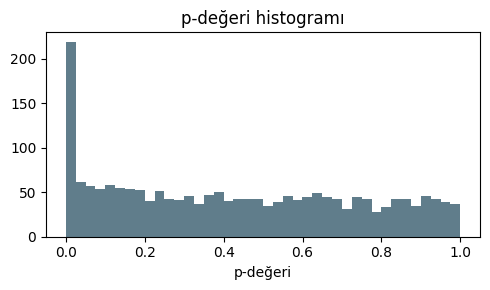

p < 0.05 olan gen sayısı: 281 | sadece şansla beklenen ≈ 97


In [10]:
kontrol = X.columns[bilgi.grup == "kontrol"]
tedavi = X.columns[bilgi.grup == "tedavi"]
sonuc = pd.DataFrame(index=X.index)
sonuc["ortalama_logCPM"] = X.mean(axis=1)
sonuc["log2FC"] = X[tedavi].mean(axis=1) - X[kontrol].mean(axis=1)
t_ist, p_deg = stats.ttest_ind(X[tedavi], X[kontrol], axis=1, equal_var=False)
sonuc["t"], sonuc["p"] = t_ist, p_deg
plt.figure(figsize=(5, 3)); plt.hist(sonuc.p, bins=40, color="#607d8b"); plt.xlabel("p-değeri"); plt.title("p-değeri histogramı")
plt.tight_layout(); plt.show()
print("p < 0.05 olan gen sayısı:", (sonuc.p < 0.05).sum(), "| sadece şansla beklenen ≈", round(0.05 * len(sonuc)))

> **p-değeri histogramı** sıfıra yakın bir tepe + düz bir taban gösteriyor. Düz taban, $H_0$'ın doğru olduğu genlerdendir (p-değerleri
$H_0$ altında düzgün dağılır). 1800+ test yaptığımız için p < 0.05 eşiği yüzlerce **yanlış pozitif** üretir!

## 5. Çoklu test düzeltmesi

| Yöntem | Kontrol ettiği | Kural |
|---|---|---|
| Bonferroni | Aile boyu hata oranı (FWER): ≥1 yanlış pozitif olasılığı | $p_i \le \alpha/m$ |
| Benjamini–Hochberg | Yanlış keşif oranı (FDR): keşiflerin içindeki yanlışların beklenen oranı | Sıralı $p_{(k)} \le \dfrac{k}{m}\alpha$ olan en büyük *k* |

### Sayısal örnek (m = 8, α = 0.05)
| Sıra k | p | Bonferroni eşiği 0.05/8 | BH eşiği k·0.05/8 | BH düzeltilmiş q |
|---|---|---|---|---|
| 1 | 0.001 | 0.00625 ✔ | 0.00625 ✔ | 0.008 |
| 2 | 0.008 | ✘ | 0.0125 ✔ | 0.032 |
| 3 | 0.039 | ✘ | 0.01875 ✘ | 0.067 |
| 4 | 0.041 | ✘ | 0.025 ✘ | 0.067 |
| 5 | 0.042 | ✘ | 0.03125 ✘ | 0.067 |
| 6 | 0.060 | ✘ | 0.0375 ✘ | 0.080 |
| 7 | 0.074 | ✘ | 0.04375 ✘ | 0.085 |
| 8 | 0.205 | ✘ | 0.05 ✘ | 0.205 |

Bonferroni 1, BH 2 keşif yapar. q değeri: $q_{(k)} = \min_{j\ge k} \dfrac{m\,p_{(j)}}{j}$.

In [11]:
def bh(p):
    p = np.asarray(p); m = len(p)
    sira = np.argsort(p)
    q = p[sira] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]          # sağdan kümülatif minimum
    cikti = np.empty(m); cikti[sira] = np.minimum(q, 1)
    return cikti

p_ornek = [0.001, 0.008, 0.039, 0.041, 0.042, 0.060, 0.074, 0.205]
print("Bizim BH  :", bh(p_ornek).round(4))
print("SciPy BH  :", stats.false_discovery_control(p_ornek).round(4))
print("Bonferroni:", np.minimum(np.array(p_ornek) * 8, 1).round(4))

Bizim BH  : [0.008  0.032  0.0672 0.0672 0.0672 0.08   0.0846 0.205 ]
SciPy BH  : [0.008  0.032  0.0672 0.0672 0.0672 0.08   0.0846 0.205 ]
Bonferroni: [0.008 0.064 0.312 0.328 0.336 0.48  0.592 1.   ]


In [12]:
sonuc["q"] = bh(sonuc.p)
sonuc["bonf"] = np.minimum(sonuc.p * len(sonuc), 1)
anlamli = (sonuc.q < 0.05) & (sonuc.log2FC.abs() > 1)
print("Ham p<0.05:", (sonuc.p < 0.05).sum(), "| Bonferroni<0.05:", (sonuc.bonf < 0.05).sum(),
      "| BH q<0.05:", (sonuc.q < 0.05).sum(), "| BH q<0.05 ve |log2FC|>1:", anlamli.sum())
sonuc.sort_values("q").head(10).round(4)

Ham p<0.05: 281 | Bonferroni<0.05: 57 | BH q<0.05: 133 | BH q<0.05 ve |log2FC|>1: 125


,ortalama_logCPM,log2FC,t,p,q,bonf
gen,,,,,,
GEN1046,6.3654,-2.6850,-20.1892,0.0,0.0,0.0000
GEN0716,9.5374,-2.8731,-16.9916,0.0,0.0,0.0000
GEN0825,13.1483,2.2877,16.8227,0.0,0.0,0.0001
GEN1380,8.5588,-2.9538,-17.2584,0.0,0.0,0.0001
GEN0275,8.9844,2.6720,15.7579,0.0,0.0,0.0000
GEN1621,7.7050,-2.5771,-16.0959,0.0,0.0,0.0000
GEN0130,10.0296,3.2587,18.3452,0.0,0.0,0.0001
GEN1886,5.7548,-2.8606,-14.3905,0.0,0.0,0.0001
GEN0312,8.1424,2.1149,13.3075,0.0,0.0,0.0002


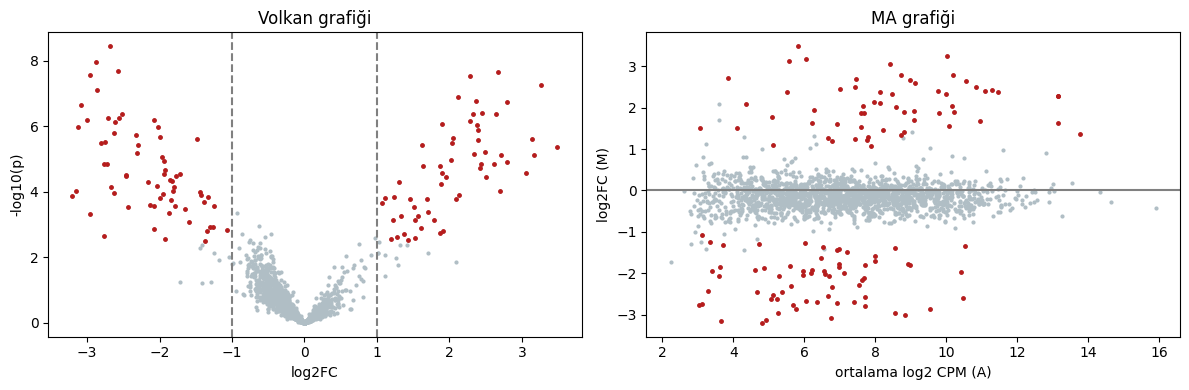

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(sonuc.log2FC, -np.log10(sonuc.p), s=4, color="#b0bec5")
ax[0].scatter(sonuc.log2FC[anlamli], -np.log10(sonuc.p[anlamli]), s=6, color="#b71c1c")
ax[0].axvline(1, ls="--", color="gray"); ax[0].axvline(-1, ls="--", color="gray")
ax[0].set_xlabel("log2FC"); ax[0].set_ylabel("-log10(p)"); ax[0].set_title("Volkan grafiği")
ax[1].scatter(sonuc.ortalama_logCPM, sonuc.log2FC, s=4, color="#b0bec5")
ax[1].scatter(sonuc.ortalama_logCPM[anlamli], sonuc.log2FC[anlamli], s=6, color="#b71c1c")
ax[1].axhline(0, color="gray"); ax[1].set_xlabel("ortalama log2 CPM (A)"); ax[1].set_ylabel("log2FC (M)"); ax[1].set_title("MA grafiği")
plt.tight_layout(); plt.show()

## 6. Gerçek cevapla karşılaştırma: karışıklık matrisi
Sentetik veri kullandığımız için hangi genlerin gerçekten DE olduğunu biliyoruz. Bu, 13. haftada makine öğrenmesi modellerini
değerlendirirken kullanacağımız ölçütlerin ilk örneğidir.

| | Gerçek DE | Gerçek DE değil |
|---|---|---|
| **Bulunan** | Doğru pozitif (TP) | Yanlış pozitif (FP) |
| **Bulunmayan** | Yanlış negatif (FN) | Doğru negatif (TN) |

Kesinlik (precision) = TP/(TP+FP), Duyarlılık (recall) = TP/(TP+FN), Gerçekleşen FDR = FP/(TP+FP).

In [14]:
gercek_set = set(gercek.gen) & set(sonuc.index)
def degerlendir(secilen):
    secilen = set(secilen)
    tp = len(secilen & gercek_set); fp = len(secilen - gercek_set); fn = len(gercek_set - secilen)
    return {"bulunan": len(secilen), "TP": tp, "FP": fp, "FN": fn,
            "kesinlik": round(tp / max(tp + fp, 1), 3), "duyarlilik": round(tp / (tp + fn), 3),
            "gerceklesen_FDR": round(fp / max(tp + fp, 1), 3)}
pd.DataFrame({
    "ham p<0.05": degerlendir(sonuc.index[sonuc.p < 0.05]),
    "Bonferroni<0.05": degerlendir(sonuc.index[sonuc.bonf < 0.05]),
    "BH q<0.05": degerlendir(sonuc.index[sonuc.q < 0.05]),
    "BH q<0.05 & |FC|>2": degerlendir(sonuc.index[anlamli]),
}).T

,bulunan,TP,FP,FN,kesinlik,duyarlilik,gerceklesen_FDR
ham p<0.05,281.0,143.0,138.0,3.0,0.509,0.979,0.491
Bonferroni<0.05,57.0,57.0,0.0,89.0,1.000,0.390,0.000
BH q<0.05,133.0,125.0,8.0,21.0,0.940,0.856,0.060
BH q<0.05 & |FC|>2,125.0,124.0,1.0,22.0,0.992,0.849,0.008


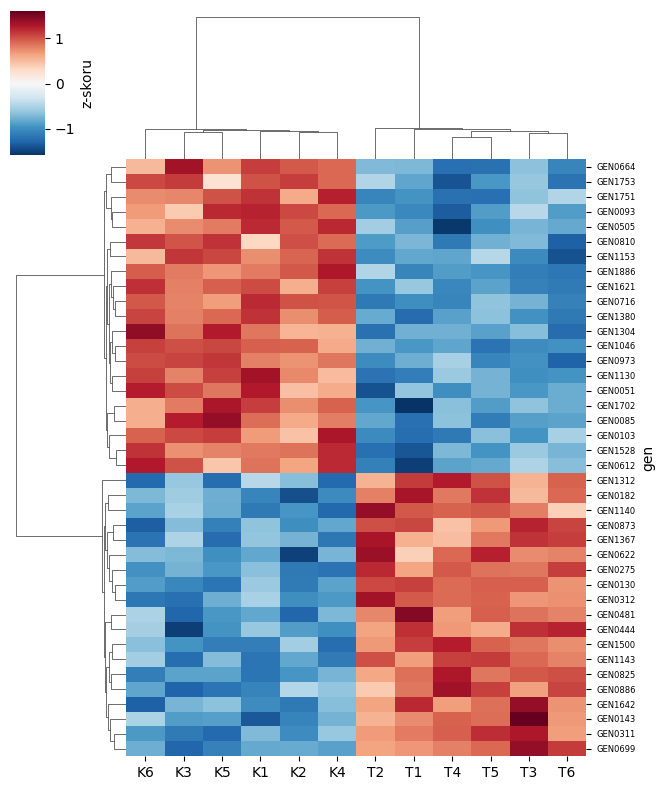

In [15]:
import seaborn as sns
en_iyi = sonuc[anlamli].sort_values("q").index[:40]
zs = X.loc[en_iyi]
zs = zs.sub(zs.mean(axis=1), axis=0).div(zs.std(axis=1), axis=0)          # gen bazında z-skoru
g = sns.clustermap(zs, cmap="RdBu_r", center=0, figsize=(7, 8), col_cluster=True, row_cluster=True,
                   yticklabels=True, cbar_kws={"label": "z-skoru"})
g.ax_heatmap.tick_params(axis="y", labelsize=6); plt.show()

## 7. Alıştırmalar
1. Bir örnekte gen X: 120 okuma, 1.5 kb; gen Y: 80 okuma, 0.5 kb; gen Z: 800 okuma, 4 kb. CPM ve TPM değerlerini elle hesaplayın.
2. p-değerleri 0.0002, 0.003, 0.01, 0.02, 0.3 için α = 0.05'te Bonferroni ve BH ile kaç keşif yapılır?
3. t-testi yerine parametrik olmayan **Mann–Whitney U** testini kullanın. n = 6'ya karşı 6 örnekle elde edilebilecek en küçük p-değeri nedir? Bu durum sonuçları nasıl etkiler?
4. Log dönüşümü yapmadan (doğrudan CPM üzerinde) t-testi uygulayın; BH q<0.05 keşiflerinin kesinlik ve duyarlılığını karşılaştırın.
5. Her gruptan yalnızca 3 örnek kullanarak (K1–K3, T1–T3) analizi tekrarlayın. Duyarlılık nasıl değişti? (İstatistiksel **güç** kavramı)

---
## Çözümler

In [16]:
# 1
d = pd.DataFrame({"okuma": [120, 80, 800], "kb": [1.5, 0.5, 4]}, index=list("XYZ"))
d["CPM"] = d.okuma / d.okuma.sum() * 1e6; d["RPK"] = d.okuma / d.kb; d["TPM"] = d.RPK / d.RPK.sum() * 1e6
print("1)\n", d.round({"CPM": 0, "RPK": 1, "TPM": 0}))
# 2
p2 = np.array([0.0002, 0.003, 0.01, 0.02, 0.3])
print("2) Bonferroni:", (p2 * 5 < 0.05).sum(), "| BH:", (bh(p2) < 0.05).sum())
# 3
u = stats.mannwhitneyu([10, 11, 12, 13, 14, 15], [1, 2, 3, 4, 5, 6], alternative="two-sided")
print(f"3) En uç ayrışmada bile Mann-Whitney p = {u.pvalue:.4f} -> 1800 test için BH ile anlamlı sonuç çıkması zor")
# 4
t4, p4 = stats.ttest_ind(cpm[tut][tedavi], cpm[tut][kontrol], axis=1, equal_var=False)
q4 = bh(p4)
print("4) CPM üzerinde:", degerlendir(cpm[tut].index[q4 < 0.05]))
print("   log2CPM üzerinde:", degerlendir(sonuc.index[sonuc.q < 0.05]))
# 5
k3, t3 = ["K1", "K2", "K3"], ["T1", "T2", "T3"]
_, p5 = stats.ttest_ind(X[t3], X[k3], axis=1, equal_var=False)
print("5) n=3:", degerlendir(X.index[bh(p5) < 0.05]))

1)
    okuma   kb       CPM    RPK       TPM
X    120  1.5  120000.0   80.0  181818.0
Y     80  0.5   80000.0  160.0  363636.0
Z    800  4.0  800000.0  200.0  454545.0
2) Bonferroni: 2 | BH: 4
3) En uç ayrışmada bile Mann-Whitney p = 0.0022 -> 1800 test için BH ile anlamlı sonuç çıkması zor
4) CPM üzerinde: {'bulunan': 101, 'TP': 96, 'FP': 5, 'FN': 50, 'kesinlik': 0.95, 'duyarlilik': 0.658, 'gerceklesen_FDR': 0.05}
   log2CPM üzerinde: {'bulunan': 133, 'TP': 125, 'FP': 8, 'FN': 21, 'kesinlik': 0.94, 'duyarlilik': 0.856, 'gerceklesen_FDR': 0.06}
5) n=3: {'bulunan': 1, 'TP': 1, 'FP': 0, 'FN': 145, 'kesinlik': 1.0, 'duyarlilik': 0.007, 'gerceklesen_FDR': 0.0}
